In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


In [2]:
df = pd.read_csv(r"D:\data_analytics\projects\upi fraud detection\upi_transactions_synthetic.csv")

print(f"dataset shape: {df.shape}")

print(f"\nFirst 5 rows")
display(df.head())

dataset shape: (80000, 18)

First 5 rows


,transaction_id,user_id,transaction_datetime,amount,merchant_id,merchant_city,merchant_category,transaction_status,device_id,device_os,location,bank_name,payment_mode_detail,promotion_applied,ip_address,is_fraud,fraud_reason,txn_failure_reason
0,T000001,U01803,2024-01-01 00:18:00,15266,M0145,Kolkata,Grocery,Success,bcd1a99b-f8fb-40a7-9400-862ce14ad744,iOS,Kolkata,HDFC,Scan & Pay,No,72.108.25.105,1,Night,NaN
1,T000002,U01582,2024-01-01 01:00:00,27919,M0289,Hyderabad,Utilities,Success,5289f75d-ac5e-4b47-bae7-4297d42244c5,iOS,Mumbai,SBI,QR,No,173.113.72.67,1,Night,NaN
2,T000003,U01582,2024-01-01 01:08:00,3765,M0235,Mumbai,Food,Success,cc03a591-5106-444a-9952-84ecd765a621,iOS,Mumbai,SBI,QR,Yes,185.194.93.75,0,NaN,NaN
3,T000004,U01620,2024-01-01 01:27:00,32801,M0061,Hyderabad,Recharge,Success,65635cef-1016-43a9-a842-09bbdf6849e3,iOS,Hyderabad,PNB,QR,Yes,30.137.234.56,1,Night,NaN
4,T000005,U00418,2024-01-01 01:46:00,38405,M0078,Kolkata,Grocery,Success,3ff8fe98-4298-45d9-9eda-3e767aae9ed8,Android,Kolkata,PNB,Scan & Pay,Yes,91.1.230.244,1,Night,NaN


In [4]:
print("\n" +"="*50)
print("DATA QUALITY CHECK")
print("="*50)


# data quality metrics

def data_quality_repost(df):
    quality_report = pd.DataFrame({
        "Data Type" : df.dtypes,
        "Missing Values" : df.isnull().sum(),
        "Missing %" : (df.isnull().sum()/len(df))*100,
        "Unique Vlaues": df.nunique(),
        "Sample values" : [df[col].dropna().unique()[:3] for col in df.columns]  # to check the first 3 non duplicate values of each column
    })
    return quality_report

quality_df = data_quality_repost(df)
display(quality_df)


DATA QUALITY CHECK


,Data Type,Missing Values,Missing %,Unique Vlaues,Sample values
transaction_id,object,0,0.0000,80000,"[T000001, T000002, T000003]"
user_id,object,0,0.0000,2000,"[U01803, U01582, U01620]"
transaction_datetime,object,0,0.0000,68304,"[2024-01-01 00:18:00, 2024-01-01 01:00:00, 202..."
amount,int64,0,0.0000,14051,"[15266, 27919, 3765]"
merchant_id,object,0,0.0000,300,"[M0145, M0289, M0235]"
merchant_city,object,0,0.0000,6,"[Kolkata, Hyderabad, Mumbai]"
merchant_category,object,0,0.0000,6,"[Grocery, Utilities, Food]"
transaction_status,object,0,0.0000,2,"[Success, Failed]"
device_id,object,0,0.0000,79977,"[bcd1a99b-f8fb-40a7-9400-862ce14ad744, 5289f75..."
device_os,object,0,0.0000,2,"[iOS, Android]"


In [ ]:
print("\n" +"="*50)
print("BASIC STATISTICS")
print("="*50)

# Basic statistics
print("Transition status distribution:")
print(df["transaction_status"].value_counts(normalize=True)*100)

print("\nFraud Distribution:")
print(f"Non Fraud: {df["is_fraud"].value_counts()[0]:,} ({df["is_fraud"].value_counts(normalize=True)[0]*100:.2f}%)")
print(f"Fraud: {df["is_fraud"].value_counts()[1]:,} ({df["is_fraud"].value_counts(normalize = True)[1]*100:.2f}%)")


print("\nFraud By Transaction Status")
fraud_by_status = df.groupby(["transaction_status", "is_fraud"]).size().unstack()    #(unstack takes on elevel and makes it column header and remaining level stays as the row index)
display(fraud_by_status)



BASIC STATISTICS
Transition status distribution:
transaction_status
Success    96.0575
Failed      3.9425
Name: proportion, dtype: float64

Fraud Distribution:
Non Fraud: 71,960 (89.95%)
Fraud: 8,040 (10.05%)

Fraud By Transaction Status


is_fraud,0,1
transaction_status,,
Failed,1446,1708
Success,70514,6332


In [6]:
# Convert to datetime

df["transaction_datetime"] = pd.to_datetime(df["transaction_datetime"])
print("Transaction_datetime column has been converted to datetime datatype")

df['transaction_date'] = df['transaction_datetime'].dt.date
df['transaction_hour'] = df['transaction_datetime'].dt.hour
df['transaction_day'] = df['transaction_datetime'].dt.day_name()
df['transaction_month'] = df['transaction_datetime'].dt.month


Transaction_datetime column has been converted to datetime datatype


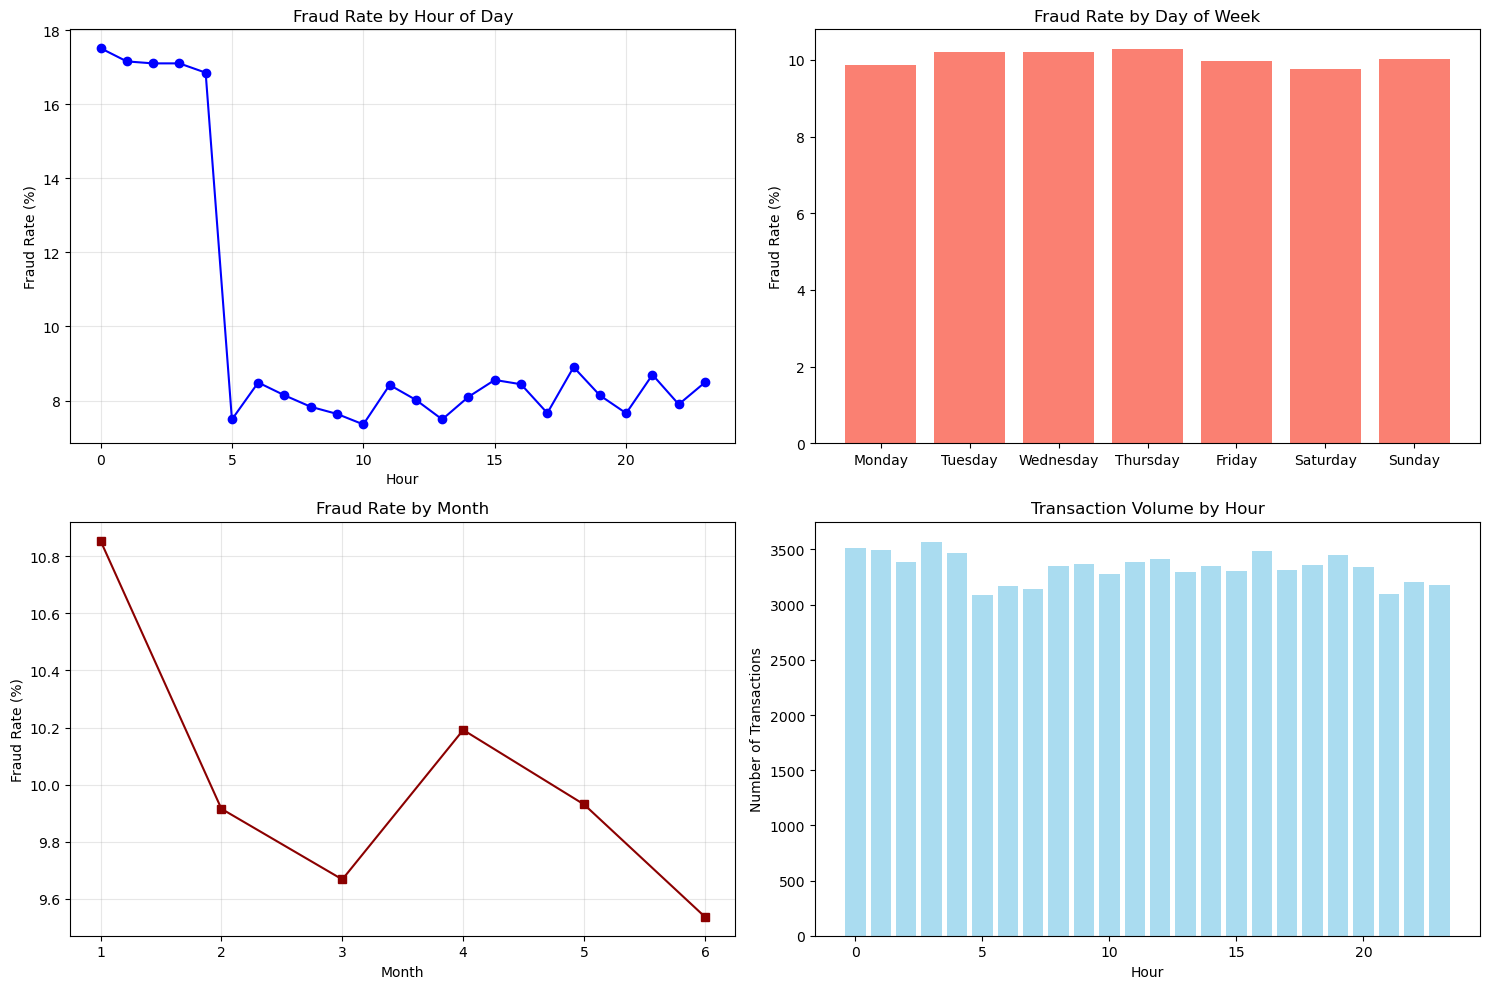

The Charts concludes that:
Night transactions need extra verification, since Fraud is highest between 1 AM to 5 AM
January and April needs investigation - what made that month different?
Daytime transactions are safer (lower fraud rate)


In [ ]:
# Temporal fraud patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))


# Fraud by hour
fraud_hour = df.groupby('transaction_hour')['is_fraud'].mean()
axes[0,0].plot(fraud_hour.index, fraud_hour.values * 100, marker='o', color='blue')
axes[0,0].set_title('Fraud Rate by Hour of Day')
axes[0,0].set_xlabel('Hour')
axes[0,0].set_ylabel('Fraud Rate (%)')
axes[0,0].grid(True, alpha=0.3)

# Fraud by day of week
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fraud_day = df.groupby('transaction_day')['is_fraud'].mean().reindex(days_order)
axes[0,1].bar(fraud_day.index, fraud_day.values * 100, color='salmon')
axes[0,1].set_title('Fraud Rate by Day of Week')
axes[0,1].set_ylabel('Fraud Rate (%)')

# Fraud by month
fraud_month = df.groupby('transaction_month')['is_fraud'].mean()
axes[1,0].plot(fraud_month.index, fraud_month.values * 100, marker='s', color='darkred')
axes[1,0].set_title('Fraud Rate by Month')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Fraud Rate (%)')
axes[1,0].grid(True, alpha=0.3)

# Transaction volume by hour
hourly_volume = df.groupby('transaction_hour').size()
axes[1,1].bar(hourly_volume.index, hourly_volume.values, color='skyblue', alpha=0.7)
axes[1,1].set_title('Transaction Volume by Hour')
axes[1,1].set_xlabel('Hour')
axes[1,1].set_ylabel('Number of Transactions')

plt.tight_layout()
plt.show()

print("The Charts concludes that:")
print("Night transactions need extra verification, since Fraud is highest between 1 AM to 5 AM")
print("January and April needs investigation - what made that month different?")
print("Daytime transactions are safer (lower fraud rate)")

# Proposed Solutions

# Problem Identified:
# - higher fraud rate between 1-5 AM
# - January shows the highest fraud rate along with april

# Recommended Actions:
# 1. **Night Transaction Protocol** (Immediate):
#    - Transactions 1-5 AM > ₹5,000 → OTP verification
#    - January transactions → Enhanced monitoring

# 2. **User Education** (Ongoing):
#    - Alerts about night-time fraud risks
#    - Transaction confirmation messages




AMOUNT ANALYSIS


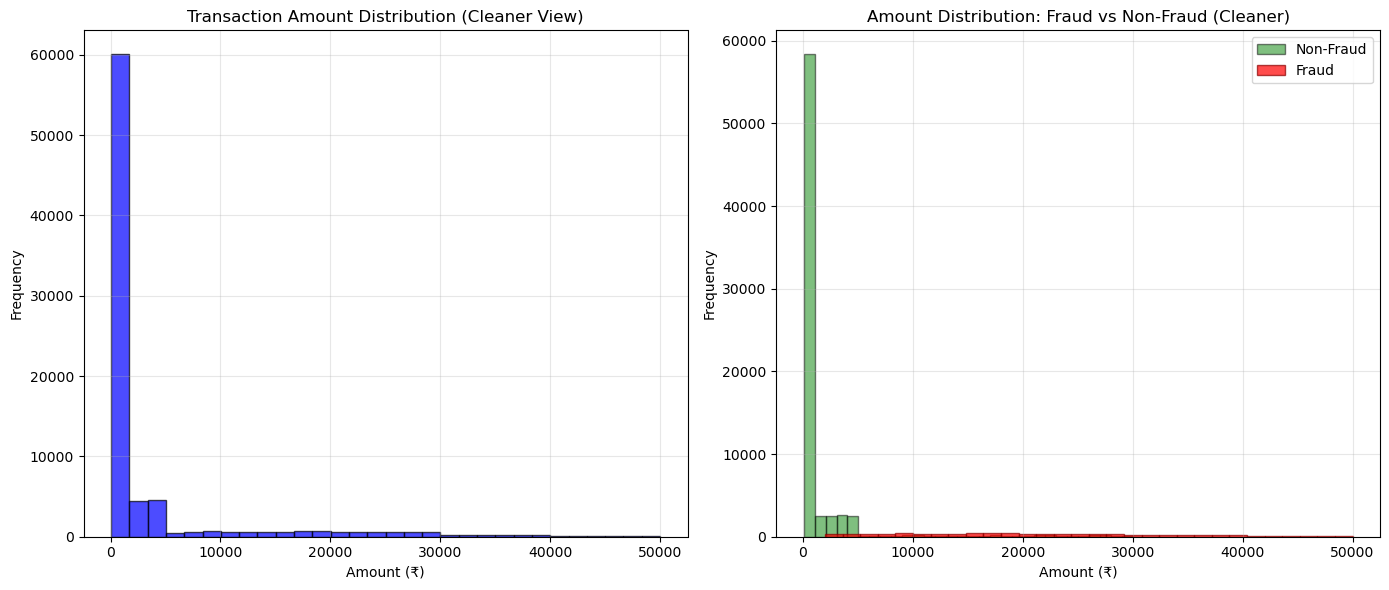

In [8]:
print("\n" + "="*50)
print("AMOUNT ANALYSIS")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: All transactions - CLEANER with 30 bars
axes[0].hist(df['amount'], bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('Transaction Amount Distribution (Cleaner View)')
axes[0].set_xlabel('Amount (₹)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Chart 2: Fraud vs Non-Fraud - CLEANER with 30 bars each
fraud_amounts = df[df['is_fraud'] == 1]['amount']
non_fraud_amounts = df[df['is_fraud'] == 0]['amount']

axes[1].hist(non_fraud_amounts, bins=30, alpha=0.5, label='Non-Fraud', color='green', edgecolor='black')
axes[1].hist(fraud_amounts, bins=30, alpha=0.7, label='Fraud', color='red', edgecolor='darkred')
axes[1].set_title('Amount Distribution: Fraud vs Non-Fraud (Cleaner)')
axes[1].set_xlabel('Amount (₹)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
print("AMOUNT & FRAUD SUMMARY")
print("="*50)

# counting transaction in simple groups
small = len(df[df["amount"] < 1000])
medium = len(df[(df["amount"] >= 1000) & (df["amount"] < 5000)])
large = len(df[(df["amount"] >= 5000) & (df["amount"] < 15000)])
huge = len(df[df["amount"] >= 15000])

print(f"Small (<₹1,000):    {small:,} transactions") 
print(f"Medium (<₹1k - 5k): {medium:,} transactions")
print(f"Large (<₹5k - 15k): {large:,} transactions")
print(f"Huge (<₹15k+):      {huge:,} transactions") 

# Add fraud counts
print("\nFRAUD BREAKDOWN:")
small_fraud = len(df[(df["amount"] < 1000) & (df["is_fraud"]==1)])
medium_fraud = len(df[(df["amount"] >= 1000) & (df["amount"] < 5000) & (df["is_fraud"]==1)])
large_fraud = len(df[(df["amount"] >= 5000) & (df["amount"] < 15000) & (df["is_fraud"]==1)])
huge_fraud = len(df[(df["amount"] >= 15000) & (df["is_fraud"]==1)])

print(f"Fraud in small:  {small_fraud:,} ({small_fraud/small*100:.1f}%)")
print(f"Fraud in Medium: {medium_fraud:,} ({medium_fraud/medium*100:.1f}%)")
print(f"Fraud in Large:  {large_fraud:,}  ({large_fraud/large*100:.1f}%)")
print(f"Fraud in Huge:   {huge_fraud:,}  ({huge_fraud/huge*100:.1f}%)")


# Add total
print("\n" + "-"*50)
total_transactions = small + medium + large + huge
total_fraud = small_fraud + medium_fraud + large_fraud + huge_fraud
print(f"TOTAL TRANSACTIONS: {total_transactions:,}")
print(f"TOTAL FRAUD:        {total_fraud:,} ({total_fraud/total_transactions*100:.1f}%)")
print("-"*50)


AMOUNT & FRAUD SUMMARY
Small (<₹1,000):    58,216 transactions
Medium (<₹1k - 5k): 10,866 transactions
Large (<₹5k - 15k): 3,622 transactions
Huge (<₹15k+):      7,296 transactions

FRAUD BREAKDOWN:
Fraud in small:  0 (0.0%)
Fraud in Medium: 609 (5.6%)
Fraud in Large:  2,249  (62.1%)
Fraud in Huge:   5,182  (71.0%)

--------------------------------------------------
TOTAL TRANSACTIONS: 80,000
TOTAL FRAUD:        8,040 (10.1%)
--------------------------------------------------


In [10]:
print("="*70)
print("FRAUD RATES BY CATEGORY (COMPLETE VIEW)")
print("="*70)

categorical_cols = ['merchant_category', 'device_os', 'location', 'bank_name', 
                   'payment_mode_detail', 'promotion_applied']

# names for display
display_names = {
    'merchant_category': 'MERCHANT TYPE',
    'device_os': 'DEVICE',
    'location': 'CITY', 
    'bank_name': 'BANK',
    'payment_mode_detail': 'PAYMENT METHOD',
    'promotion_applied': 'PROMOTION USED'
}

for col in categorical_cols:
    print(f"\n{display_names[col]}:")
    print("-"*50)
    
    # Calculating fraud rate for each category
    fraud_data = df.groupby(col)['is_fraud'].mean() * 100
    
    # Sort from highest to lowest fraud
    fraud_data = fraud_data.sort_values(ascending=False)
    
    # Printjng each category
    for category, rate in fraud_data.items():
        count = len(df[df[col] == category])
        fraud_count = int(count * rate / 100)
        print(f"   {category}: {rate:.1f}% fraud ({fraud_count:,} fraud transactions)")


FRAUD RATES BY CATEGORY (COMPLETE VIEW)

MERCHANT TYPE:
--------------------------------------------------
   Shopping: 10.4% fraud (1,345 fraud transactions)
   Grocery: 10.2% fraud (1,353 fraud transactions)
   Travel: 10.2% fraud (1,412 fraud transactions)
   Food: 9.9% fraud (1,289 fraud transactions)
   Utilities: 9.8% fraud (1,344 fraud transactions)
   Recharge: 9.8% fraud (1,297 fraud transactions)

DEVICE:
--------------------------------------------------
   Android: 10.1% fraud (4,050 fraud transactions)
   iOS: 10.0% fraud (3,990 fraud transactions)

CITY:
--------------------------------------------------
   Hyderabad: 10.5% fraud (1,365 fraud transactions)
   Bangalore: 10.3% fraud (1,429 fraud transactions)
   Mumbai: 10.2% fraud (1,342 fraud transactions)
   Delhi: 9.9% fraud (1,397 fraud transactions)
   Chennai: 9.9% fraud (1,289 fraud transactions)
   Kolkata: 9.5% fraud (1,217 fraud transactions)

BANK:
--------------------------------------------------
   ICICI: 10

In [ ]:
# Summary of Key Findings:

# Overall Fraud Rate: The dataset of 80,000 transactions has a significant fraud rate of 10.05% (8,040 transactions).

# Status & Fraud Link: A large portion of fraudulent transactions (1,708 out of 8,040) result in a "Failed" status, 
# indicating fraud detection or blocking may be occurring during processing.

# Critical Amount Risk: Fraud is heavily concentrated in high-value transactions.

# Large (₹5k-15k): 62.1% fraud rate.

# Huge (₹15k+): 71.0% fraud rate.

# In contrast, Small (<₹1k) transactions show 0% fraud.

# Patterns by Category: Fraud rates are relatively consistent across most categories 
# (merchant type, device, city, bank, payment method), typically hovering around the 10% average, with minor variations.

# Temporal Patterns (from charts): The data suggests fraud rates and transaction volumes fluctuate by hour of the day and 
# day of the week, indicating potential time-based patterns in fraudulent activity.

# Next Step: We will proceed with pattern analysis on these findings to uncover deeper insights, correlations, and actionable 
# intelligence for fraud detection.
